# Flat Transducer + Silicone Lens -> Brain Focus  (minimal)

A flat 20 mm transducer with a **plano-convex silicone lens** (slow -> converging). Two experiments:

1. **Homogeneous bath** -- the medium is "water" set to **brain properties** (c=1560, rho=1040) everywhere.
   Shows the lens's focus with no interfaces to confuse things.
2. **On the brain** -- the same transducer+lens sits on top of the brain with an **axial gap left for a phase
   plate**; everything outside the brain is **air**. Shows how the real geometry + air boundary change the focus.

| material | c (m/s) | rho (kg/m^3) |
|----------|---------|-----------|
| brain / coupling "water" | 1560 | 1040 |
| silicone lens | 1000 | 1030 |
| air (outside brain) | 343 | 100* |

\*air density is a numerical-stability floor (see params), not literal 1.2.

## 1. Imports

In [18]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from scipy import ndimage
from scipy.ndimage import gaussian_filter

from kwave.kgrid import kWaveGrid
from kwave.kmedium import kWaveMedium
from kwave.ksource import kSource
from kwave.ksensor import kSensor
from kwave.kspaceFirstOrder import kspaceFirstOrder
from kwave.utils.signals import tone_burst
np.set_printoptions(suppress=True, precision=3)
print("imports OK")

imports OK


## Parameters

In [19]:
BRAIN_NII = r"C:\Users\bengi\Documents\Pesaran Lab\brain_mask.nii"

freq   = 500e3                       # Hz
dx     = 0.5e-3                      # m (= brain voxel size)

c_med,  rho_med  = 1560.0, 1040.0    # brain == coupling "water"
c_lens, rho_lens = 1000.0, 1030.0    # silicone
c_air            = 343.0
rho_air          = 100.0             # STABILITY FLOOR (not 1.2): air is under-resolved at
                                     # 0.5 mm and the huge density jump NaNs the solver;
                                     # 100 still reflects ~93%. Air only borders the beam.
SMOOTH_MED_VOX   = 0.6               # light smoothing of c/rho maps (k-Wave stability)

TX_DIAM  = 20e-3                      # flat transducer diameter
r_tx     = TX_DIAM/2
FOCAL    = 28e-3                      # m, lens focal length from the transducer face
P0       = 1e5                       # Pa
N_CYCLES = 5
CROP_PAD = 5e-3                      # m, margin added around an aperture/extent when sizing a sim domain
LAT_HALF = r_tx + CROP_PAD            # m, half-width of the homogeneous-bath sim domain (step 3)

# phase plate (stamped after the lens, same silicone)
PLATE_MODE   = "targeted"             # "none" / "random" (exploratory) / "targeted" (aim for TARGET_VOX)
PLATE_MAX_T  = 3e-3                   # m, max extra thickness -- "random" mode only
PLATE_SMOOTH = 3e-3                   # m, smoothing length of the random pattern (~1 wavelength) -- "random" only
PLATE_SEED   = 0
TARGET_VOX   = (98, 88, 43)           # local voxel frame, same as the FOCUS voxel printed in step 4 --
                                       # default = original lens-only focus (88,88,43) +10vox(=5mm) in x

# step-4 placement (transducer on top of the brain, beam pointing inferior)
STANDOFF    = 12e-3                   # face -> brain-surface gap (lens + phase-plate space)
R_COUPLE    = 14e-3                   # coupling-bath cylinder radius
Z_MARGIN    = 8                       # voxels above the transducer face

m2v = lambda m: m/dx
lam = c_med/freq
print(f"freq {freq/1e3:.0f} kHz | lambda(brain) {lam*1e3:.2f} mm = {lam/dx:.1f} vox")
print(f"flat-disc natural near field D^2/(4 lambda) = {(TX_DIAM**2/(4*lam))*1e3:.0f} mm; design focal {FOCAL*1e3:.0f} mm")

freq 500 kHz | lambda(brain) 3.12 mm = 6.2 vox
flat-disc natural near field D^2/(4 lambda) = 32 mm; design focal 28 mm


## Lens design

Plano-convex silicone, flat on the transducer, convex toward the focus. Thickness `t(r)` equalises the travel
time of every ray to the on-axis focus at `FOCAL` in the brain-speed medium:

`t(r) = [sqrt(r_max^2+F^2) - sqrt(r^2+F^2)] / [c_med (1/c_lens - 1/c_med)]`  (thickest at the centre).

lens centre thickness 3.09 mm  (rim 0)


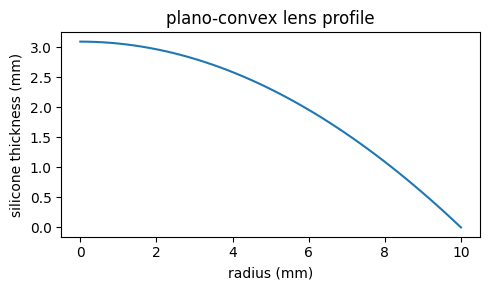

In [20]:
def lens_thickness(r):
    # r: radius (m), returns silicone thickness (m); 0 outside the aperture
    t = (np.sqrt(r_tx**2 + FOCAL**2) - np.sqrt(r**2 + FOCAL**2)) / (c_med*(1/c_lens - 1/c_med))
    return np.where(r <= r_tx, np.maximum(t, 0.0), 0.0)

def stamp_lens(c_map, rho_map, z_face, xc, yc):
    # carve the plano-convex silicone lens into a medium, on the z=z_face plane, centred (xc,yc)
    Nx, Ny, Nz = c_map.shape
    xx, yy = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing="ij")
    r = np.sqrt(((xx-xc)*dx)**2 + ((yy-yc)*dx)**2)
    tv = np.round(lens_thickness(r)/dx).astype(int)           # thickness in voxels per column
    zz = np.arange(Nz)[None,None,:]
    lens = (zz >= z_face) & (zz < z_face + tv[:,:,None]) & (r[:,:,None] <= r_tx)
    c_map[lens], rho_map[lens] = c_lens, rho_lens
    return lens

rr = np.linspace(0, r_tx, 50)
print(f"lens centre thickness {lens_thickness(np.array([0.0]))[0]*1e3:.2f} mm  (rim 0)")
plt.figure(figsize=(5,3)); plt.plot(rr*1e3, lens_thickness(rr)*1e3)
plt.xlabel("radius (mm)"); plt.ylabel("silicone thickness (mm)"); plt.title("plano-convex lens profile")
plt.tight_layout(); plt.show()

## Phase plate (random + targeted)

A second, thinner silicone element stamped in the standoff gap, right after the (fixed) lens. Two ways to choose
its thickness pattern `t(x,y)`:

- **random** -- smooth random field, just to check that perturbing the wavefront after the lens moves the focus
  at all.
- **targeted** -- same Fermat/equal-time-delay idea as the lens design, generalised to an arbitrary (possibly
  off-axis) target point instead of the on-axis `FOCAL` point: for every aperture point, add just enough extra
  silicone so the total travel time (through the existing lens, then this plate, then straight to the target)
  is the same everywhere, so the wave reconstructs in phase at the target instead of at the lens's natural focus.

In [21]:
def stamp_plate(c_map, rho_map, z_start, thickness_map):
    # carve an arbitrary silicone thickness pattern into a medium, starting at z_start
    Nx, Ny, Nz = c_map.shape
    tv = np.round(thickness_map/dx).astype(int)
    zz = np.arange(Nz)[None,None,:]
    plate = (zz >= z_start) & (zz < z_start + tv[:,:,None])
    c_map[plate], rho_map[plate] = c_lens, rho_lens
    return plate

def random_plate_thickness(Nx, Ny, xc, yc, max_t, smooth_m, seed):
    # smooth (not per-voxel) random field, masked to the transducer aperture -- smoothing keeps the
    # pattern coherent over roughly a wavelength instead of scattering the beam into noise
    rng = np.random.default_rng(seed)
    raw = gaussian_filter(rng.standard_normal((Nx, Ny)), smooth_m/dx)
    raw -= raw.min(); raw /= raw.max()
    xx, yy = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing="ij")
    r = np.sqrt(((xx-xc)*dx)**2 + ((yy-yc)*dx)**2)
    return np.where(r <= r_tx, raw*max_t, 0.0)

def targeted_plate_thickness(Nx, Ny, xc, yc, z_face, target_vox):
    # thickness pattern that, ADDED ON TOP of the existing fixed lens, equalises total travel time from
    # every aperture point to target_vox (local voxel frame) -- thin-screen approximation (each element
    # just adds time delay = thickness * (1/c_lens - 1/c_med), same approximation lens_thickness() uses)
    xx, yy = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing="ij")
    ax_m, ay_m = (xx-xc)*dx, (yy-yc)*dx
    r = np.sqrt(ax_m**2 + ay_m**2)
    tx_m, ty_m, tz_m = (np.array(target_vox, float) - [xc, yc, z_face]) * dx
    dist = np.sqrt((ax_m-tx_m)**2 + (ay_m-ty_m)**2 + tz_m**2)        # aperture point -> target
    already = dist/c_med + lens_thickness(r)*(1/c_lens - 1/c_med)    # time already "spent" getting there
    mask = r <= r_tx
    T0 = already[mask].max()                                        # calibrate so min thickness = 0
    return np.where(mask, (T0 - already)/(1/c_lens - 1/c_med), 0.0)
print("phase-plate helpers ready")

phase-plate helpers ready


## Reachable focal volume (how far can the plate steer?)

Pure geometry/math, no simulation: for a candidate target, `targeted_plate_thickness` needs a max thickness equal
to the *spread* (max-min across the aperture) of `already(x,y) = dist/c_med + lens delay`, divided by the
material's delay rate. That max thickness is capped by the space actually available above the lens (the standoff
gap minus the lens's own thickness minus a safety margin so the plate doesn't touch the brain). Sweeping target
position against that budget maps out which targets are physically buildable.

By the lens's radial symmetry, feasibility only depends on the target's **lateral distance from the beam axis**
and **depth from the face** -- not direction -- so a 2D (depth x lateral) sweep fully characterises the 3D
reachable volume (a solid of revolution around the beam axis). As a sanity check: at the lens's own natural focus
(on-axis, depth=`FOCAL`), the required thickness comes out to exactly 0 -- the lens alone already focuses there.

plate thickness budget: 7.9 mm (standoff 12 - lens centre 3.1 - 1mm margin)
feasible region: depth 6-60 mm, lateral up to 14 mm (at the most permissive depth)


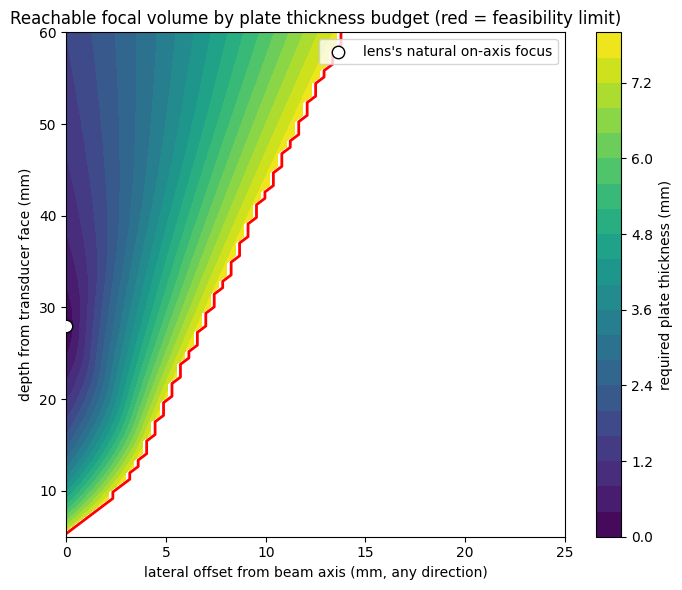

In [22]:
gap_margin = 1e-3                                                    # m, keep the plate clear of the brain surface
lens_ctr = lens_thickness(np.array([0.0]))[0]
T_BUDGET = STANDOFF - lens_ctr - gap_margin
print(f"plate thickness budget: {T_BUDGET*1e3:.1f} mm (standoff {STANDOFF*1e3:.0f} - lens centre {lens_ctr*1e3:.1f} - {gap_margin*1e3:.0f}mm margin)")

xa, ya = np.meshgrid(np.linspace(-r_tx, r_tx, 120), np.linspace(-r_tx, r_tx, 120), indexing="ij")
r_ap = np.sqrt(xa**2 + ya**2); ap_mask = r_ap <= r_tx
lt_ap = lens_thickness(r_ap)

lat_grid = np.linspace(0, 25e-3, 60)          # candidate lateral target offset, any direction (0-25mm)
z_grid   = np.linspace(5e-3, 60e-3, 80)       # candidate target depth from the face (5-60mm)
need = np.full((len(z_grid), len(lat_grid)), np.nan)
for iz, z_t in enumerate(z_grid):
    for il, lat_t in enumerate(lat_grid):
        dist = np.sqrt((xa-lat_t)**2 + ya**2 + z_t**2)
        already = dist/c_med + lt_ap*(1/c_lens - 1/c_med)
        a = already[ap_mask]
        need[iz, il] = (a.max() - a.min()) / (1/c_lens - 1/c_med)

feasible = need <= T_BUDGET
print(f"feasible region: depth {z_grid[feasible.any(1)].min()*1e3:.0f}-{z_grid[feasible.any(1)].max()*1e3:.0f} mm, "
      f"lateral up to {lat_grid[feasible.any(0)].max()*1e3:.0f} mm (at the most permissive depth)")

plt.figure(figsize=(7,6))
plt.contourf(lat_grid*1e3, z_grid*1e3, np.where(feasible, need*1e3, np.nan), levels=20, cmap="viridis")
plt.colorbar(label="required plate thickness (mm)")
plt.contour(lat_grid*1e3, z_grid*1e3, feasible.astype(float), levels=[0.5], colors="red", linewidths=2)
plt.scatter([0], [FOCAL*1e3], c="white", edgecolor="k", s=80, zorder=5, label="lens's natural on-axis focus")
plt.xlabel("lateral offset from beam axis (mm, any direction)"); plt.ylabel("depth from transducer face (mm)")
plt.title("Reachable focal volume by plate thickness budget (red = feasibility limit)")
plt.legend(); plt.tight_layout(); plt.show()

## 2. Load brain

In [23]:
img = nib.load(BRAIN_NII)
brain = ndimage.binary_fill_holes(img.get_fdata() > 0.5)
brain = np.rot90(brain, k=1, axes=(0,1))   # fix: was hitting front of brain instead of top
brain = np.flip(brain, axis=1)             # fix: was upside-down after the rotation above
NX, NY, NZ = brain.shape
C = np.argwhere(brain).mean(0)
print(f"brain {brain.shape} @ {dx*1e3:.1f} mm | axcodes {nib.aff2axcodes(img.affine)} | centroid {np.round(C,0)}")
print(f"(voxel axes (i,j,k) -> (P,I,R): superior=-j, so 'top of brain' = small j)")

brain (256, 256, 208) @ 0.5 mm | axcodes ('P', 'I', 'R') | centroid [112.  79. 100.]
(voxel axes (i,j,k) -> (P,I,R): superior=-j, so 'top of brain' = small j)


### sim + focus helpers

In [24]:
def run_sim(c_map, rho_map, z_face, xc, yc, t_end):
    Nx, Ny, Nz = c_map.shape
    kgrid = kWaveGrid([Nx, Ny, Nz], [dx, dx, dx])
    kgrid.makeTime(c_med, cfl=0.3, t_end=t_end)
    if SMOOTH_MED_VOX > 0:
        c_map   = gaussian_filter(c_map,   SMOOTH_MED_VOX).astype(np.float32)
        rho_map = gaussian_filter(rho_map, SMOOTH_MED_VOX).astype(np.float32)
    medium = kWaveMedium(sound_speed=c_map, density=rho_map)
    disc = (np.sqrt((np.arange(Nx)[:,None]-xc)**2 + (np.arange(Ny)[None,:]-yc)**2)*dx) <= r_tx
    src = kSource(); src.p_mask = np.zeros((Nx,Ny,Nz), np.uint8); src.p_mask[:,:,z_face] = disc
    src.p = (tone_burst(1/kgrid.dt, freq, N_CYCLES).flatten()*P0).reshape(1,-1)   # flat, in-phase
    sen = kSensor(); sen.mask = np.ones((Nx,Ny,Nz), np.uint8); sen.record = ["p_max"]
    print(f"  grid {Nx}x{Ny}x{Nz}  Nt {kgrid.Nt}  ... running (GPU)")
    sd = kspaceFirstOrder(kgrid, medium, src, sen, device="gpu", dtype="float32")
    p = np.zeros((Nx,Ny,Nz), np.float32); p[sen.mask.astype(bool)] = np.squeeze(np.asarray(sd["p_max"]))
    nbad = int((~np.isfinite(p)).sum())
    if nbad: print(f"  WARNING {nbad} non-finite voxels -> instability; zeroing"); p = np.nan_to_num(p)
    return p

def focus_of(p, mask=None):
    pm = np.nan_to_num(p if mask is None else np.where(mask, p, 0.0))
    fi = np.unravel_index(np.argmax(pm), pm.shape)
    return fi, float(pm.max())
print("helpers ready")

helpers ready


## 3. Lens in a homogeneous bath (water = brain)

Medium is brain-property "water" everywhere, with the silicone lens on the transducer face. A flat in-phase disc
fires; the lens focuses it. We read off the focal depth from the transducer face.

In [25]:
Nx = Ny = 2*int(round(m2v(LAT_HALF)))
Nz = Z_MARGIN + int(round(m2v(FOCAL))) + 28
xc = yc = Nx//2; z_face = Z_MARGIN

c_map   = np.full((Nx,Ny,Nz), c_med,   np.float32)
rho_map = np.full((Nx,Ny,Nz), rho_med, np.float32)
lens = stamp_lens(c_map, rho_map, z_face, xc, yc)

t_end = 1.2*(Nz*dx)/c_med
p3 = run_sim(c_map.copy(), rho_map.copy(), z_face, xc, yc, t_end)
fi, pk = focus_of(p3, mask=~lens)   # exclude the lens: its own near-source resonance can outpeak the true downstream focus
depth = (fi[2]-z_face)*dx*1e3
print(f"FOCUS voxel {fi} | depth from face {depth:.1f} mm (design ref {FOCAL*1e3:.0f}) | "
      f"lateral off-axis {np.hypot(fi[0]-xc,fi[1]-yc)*dx*1e3:.1f} mm | peak {pk/1e3:.1f} kPa")

  grid 60x60x92  Nt 369  ... running (GPU)


k-Wave: 100%|██████████| 369/369 [00:01<00:00, 252.37step/s]


FOCUS voxel (np.int64(30), np.int64(30), np.int64(45)) | depth from face 18.5 mm (design ref 28) | lateral off-axis 0.0 mm | peak 426.2 kPa


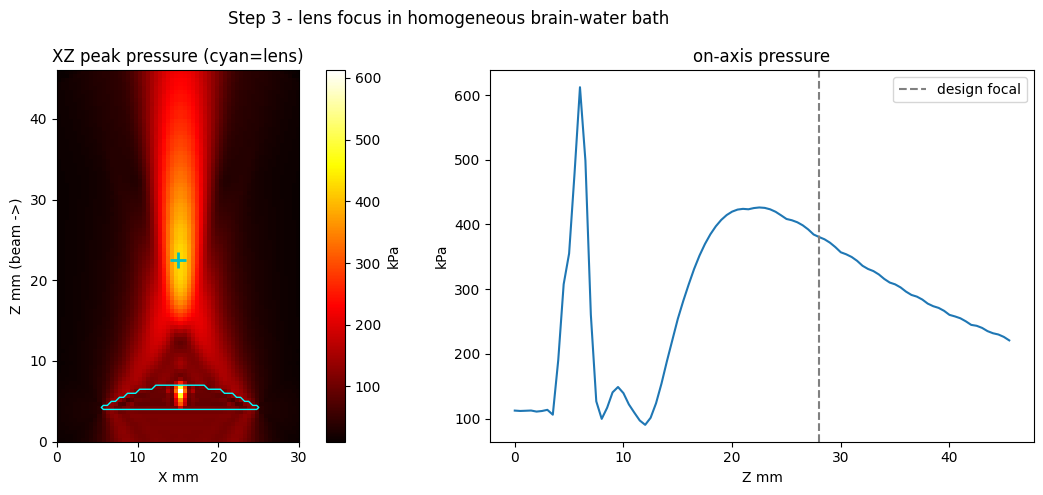

In [26]:
ex=[0,Nx*dx*1e3]; ez=[0,Nz*dx*1e3]
fig,ax=plt.subplots(1,2,figsize=(12,5))
im=ax[0].imshow(p3[:,yc,:].T/1e3,origin="lower",extent=ex+ez,cmap="hot",aspect="equal")
ax[0].contour(lens[:,yc,:].T,levels=[0.5],colors="cyan",linewidths=1,extent=ex+ez,origin="lower")
ax[0].plot(fi[0]*dx*1e3, fi[2]*dx*1e3,"c+",ms=12,mew=2)
ax[0].set(title="XZ peak pressure (cyan=lens)",xlabel="X mm",ylabel="Z mm (beam ->)"); plt.colorbar(im,ax=ax[0],label="kPa")
ax[1].plot(np.arange(Nz)*dx*1e3, p3[xc,yc,:]/1e3)
ax[1].axvline(FOCAL*1e3,ls="--",c="gray",label="design focal")
ax[1].set(title="on-axis pressure",xlabel="Z mm",ylabel="kPa"); ax[1].legend()
plt.suptitle("Step 3 - lens focus in homogeneous brain-water bath"); plt.tight_layout(); plt.show()

## 4. Transducer + lens on top of the brain (air outside, gap for phase plate)

Crop a block at the picked transducer pose (beam = local +Z). If `transducer_location.json` exists (saved by
`place_transducer.py`), the brain is **rotated into that beam-aligned frame**; otherwise it defaults to straight-up
at the brain's superior-most point. The transducer+lens sits a `STANDOFF` above the brain surface; the space
between the lens and the brain is coupling "water" (= brain) and **is where the phase plate will go**. Everything
outside the brain (and outside the coupling cylinder) is **air**.

In [27]:
# transducer pose: load the picked location from place_transducer.py if saved, else default to straight-up
TX_JSON = "transducer_location.json"
if os.path.exists(TX_JSON):
    tj = json.load(open(TX_JSON))
    face_vox = np.array(tj["transducer_face_center_voxel"], float)
    n_out = np.array(tj["beam_normal_voxel"], float); n_out /= np.linalg.norm(n_out)
    standoff_use = tj["standoff_mm"]*1e-3
    print(f"using PICKED pose from {TX_JSON}: beam {tj['equiv_angles_deg']}, standoff {tj['standoff_mm']} mm, {tj['anat_offset']}")
else:
    ic0, kc0 = int(round(C[0])), int(round(C[2]))
    j_top = int(np.argmax(brain[ic0, :, kc0]))
    n_out = np.array([0., -1., 0.])                        # outward = superior = -j
    face_vox = np.array([ic0, j_top, kc0], float) + n_out*m2v(STANDOFF)
    standoff_use = STANDOFF
    print(f"no {TX_JSON} found -> default straight-up placement at brain top")

# rotate the brain into a beam-aligned local frame: local +z (last axis) = beam direction (into the brain)
beam = -n_out; e3 = beam/np.linalg.norm(beam)
tmp = np.array([0.,0.,1.]) if abs(e3[2]) < 0.9 else np.array([1.,0.,0.])
e1 = np.cross(tmp, e3); e1 /= np.linalg.norm(e1); e2 = np.cross(e3, e1)
Mrot = np.stack([e1, e2, e3])                              # local = Mrot @ (world_vox - origin)

# size the crop to cover the WHOLE brain, not a small patch: project every brain voxel into this
# beam-aligned frame and take its full extent + a margin. This is much bigger than the old fixed-size
# patch -> the sim below will take a lot longer and use a lot more memory.
local = (np.argwhere(brain) - face_vox) @ Mrot.T            # columns = e1,e2,e3 coords relative to face
pad = m2v(CROP_PAD)
soff = int(round(m2v(standoff_use)))
LAT  = int(np.ceil(np.abs(local[:,:2]).max() + pad))
Nx = Ny = 2*LAT; xc = yc = LAT; z_face = Z_MARGIN
Nz = Z_MARGIN + int(np.ceil(local[:,2].max() + pad))
origin = face_vox - e3*z_face
offset = origin - Mrot.T @ np.array([xc, yc, 0.])
brain_W = ndimage.affine_transform(brain.astype(np.float32), matrix=Mrot.T, offset=offset,
                                    output_shape=(Nx,Ny,Nz), order=1) > 0.5
nvox = Nx*Ny*Nz
print(f"crop {brain_W.shape} = {Nx*dx*1e3:.0f}x{Ny*dx*1e3:.0f}x{Nz*dx*1e3:.0f} mm ({nvox/1e6:.1f}M voxels, whole brain)")
print(f"beam dir (voxel) {np.round(beam,3)}  brain top at z={soff+z_face} (= {standoff_use*1e3:.0f} mm below face)")

# clearance check: the standoff gap (face -> brain) must be brain-free under the transducer itself (r_tx),
# and ideally under the wider coupling margin (R_COUPLE) too, since brain curvature can intrude there first
xx0,yy0 = np.meshgrid(np.arange(Nx),np.arange(Ny),indexing="ij")
rad = np.sqrt((xx0-xc)**2+(yy0-yc)**2)*dx
gap = brain_W[:,:,z_face:z_face+soff]
nbad_tx     = int(gap[rad <= r_tx].sum())
nbad_couple = int(gap[rad <= R_COUPLE].sum())
print(f"clearance check: brain voxels in standoff gap -- under transducer (r<={r_tx*1e3:.0f}mm): {nbad_tx} (want 0)"
      f"{'  TOO CLOSE!' if nbad_tx else '  OK'}; "
      f"under coupling margin (r<={R_COUPLE*1e3:.0f}mm): {nbad_couple}"
      f"{'  (rim only, OK if 0 under transducer)' if nbad_couple and not nbad_tx else ''}")

no transducer_location.json found -> default straight-up placement at brain top
crop (176, 176, 147) = 88x88x74 mm (4.6M voxels, whole brain)
beam dir (voxel) [-0.  1. -0.]  brain top at z=32 (= 12 mm below face)
clearance check: brain voxels in standoff gap -- under transducer (r<=10mm): 0 (want 0)  OK; under coupling margin (r<=14mm): 0


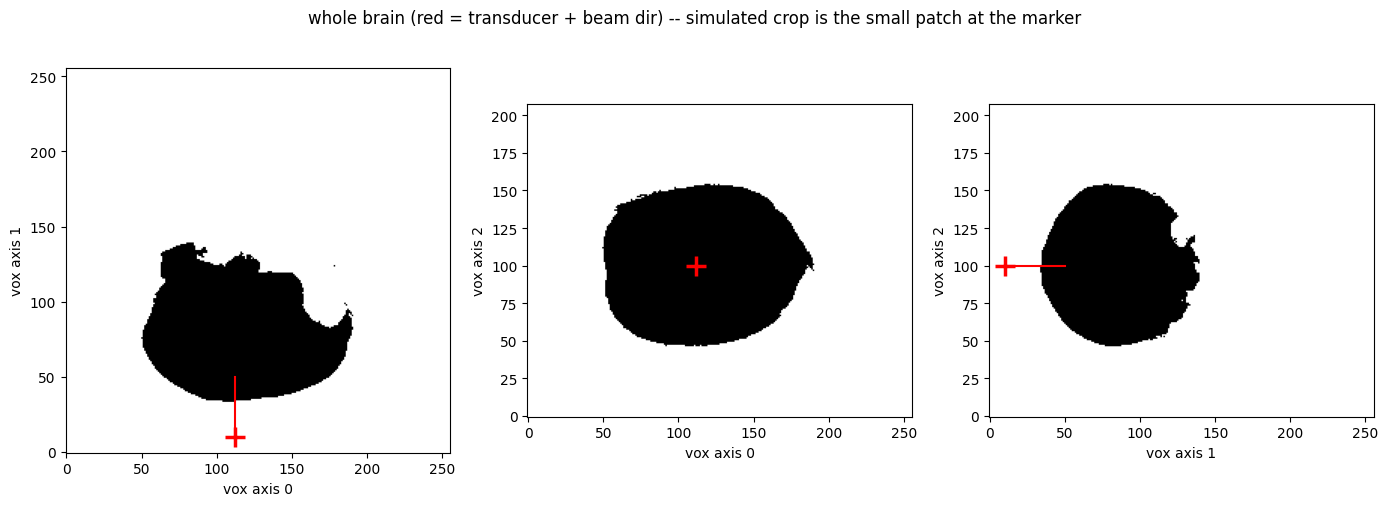

In [28]:
# whole-brain context: the simulation only covers a small crop around the transducer (compute cost) --
# this shows where that crop sits on the FULL brain, before spending time running the sim
bij = brain.any(2); bik = brain.any(1); bjk = brain.any(0)   # full-brain outlines, native (i,j,k) frame
fig,ax = plt.subplots(1,3,figsize=(14,5))
for a,foot,(h,v) in zip(ax, [bij,bik,bjk], [(0,1),(0,2),(1,2)]):
    a.imshow(foot.T, origin="lower", cmap="gray_r", aspect="equal")
    a.plot(face_vox[h], face_vox[v], "r+", ms=14, mew=2.5)
    a.plot([face_vox[h], face_vox[h]+beam[h]*40], [face_vox[v], face_vox[v]+beam[v]*40], "r-", lw=1.5)
    a.set(xlabel=f"vox axis {h}", ylabel=f"vox axis {v}")
plt.suptitle("whole brain (red = transducer + beam dir) -- simulated crop is the small patch at the marker")
plt.tight_layout(); plt.show()

In [29]:
# per-column brain surface + coupling cylinder (water=brain) between face and brain
surfz = np.full((Nx,Ny), Nz, int); anyb = brain_W.any(2); surfz[anyb] = brain_W.argmax(2)[anyb]
xx,yy = np.meshgrid(np.arange(Nx),np.arange(Ny),indexing="ij")
r2d = np.sqrt(((xx-xc)*dx)**2+((yy-yc)*dx)**2); zz=np.arange(Nz)[None,None,:]
couple = (r2d<=R_COUPLE)[:,:,None] & (zz>=z_face) & (zz<surfz[:,:,None]) & ~brain_W

c_map   = np.full((Nx,Ny,Nz), c_air,   np.float32)
rho_map = np.full((Nx,Ny,Nz), rho_air, np.float32)
c_map[couple]=c_med;  rho_map[couple]=rho_med
c_map[brain_W]=c_med; rho_map[brain_W]=rho_med            # brain == water
lensW = stamp_lens(c_map, rho_map, z_face, xc, yc)

plateW = np.zeros((Nx,Ny,Nz), bool)
if PLATE_MODE != "none":
    z_plate = z_face + int(lensW.sum(2).max())             # right after the lens, same column-wise
    if PLATE_MODE == "random":
        plate_t = random_plate_thickness(Nx, Ny, xc, yc, PLATE_MAX_T, PLATE_SMOOTH, PLATE_SEED)
    elif PLATE_MODE == "targeted":
        plate_t = targeted_plate_thickness(Nx, Ny, xc, yc, z_face, TARGET_VOX)
        off_mm = (np.array(TARGET_VOX, float) - [xc, yc, z_face]) * dx * 1e3
        print(f"phase plate [targeted]: target voxel {TARGET_VOX} = {np.round(off_mm,1)} mm (x,y,z) from face/beam axis")
    else:
        raise ValueError(f"unknown PLATE_MODE {PLATE_MODE!r}")
    plateW = stamp_plate(c_map, rho_map, z_plate, plate_t)
    nbad_plate = int((plateW & brain_W).sum())
    print(f"phase plate [{PLATE_MODE}]: z>={z_plate}, max thickness {plate_t.max()*1e3:.2f} mm, "
          f"overlap with brain: {nbad_plate}{'  TOO DEEP!' if nbad_plate else '  OK'}")

tissue = np.zeros((Nx,Ny,Nz),np.uint8); tissue[couple]=1; tissue[brain_W]=2; tissue[lensW]=3; tissue[plateW]=4
t_end = 1.2*(Nz*dx)/c_med
p4 = run_sim(c_map.copy(), rho_map.copy(), z_face, xc, yc, t_end)
fi4, pk4 = focus_of(p4, mask=brain_W)
print(f"FOCUS voxel {fi4} | depth below brain surface {(fi4[2]-surfz[fi4[0],fi4[1]])*dx*1e3:.1f} mm | peak {pk4/1e3:.1f} kPa")

phase plate [targeted]: target voxel (98, 88, 43) = [ 5.   0.  17.5] mm (x,y,z) from face/beam axis
phase plate [targeted]: z>=14, max thickness 8.66 mm, overlap with brain: 0  OK
  grid 176x176x147  Nt 589  ... running (GPU)


k-Wave: 100%|██████████| 589/589 [01:13<00:00,  8.02step/s]


FOCUS voxel (np.int64(95), np.int64(88), np.int64(41)) | depth below brain surface 4.0 mm | peak 1261.2 kPa


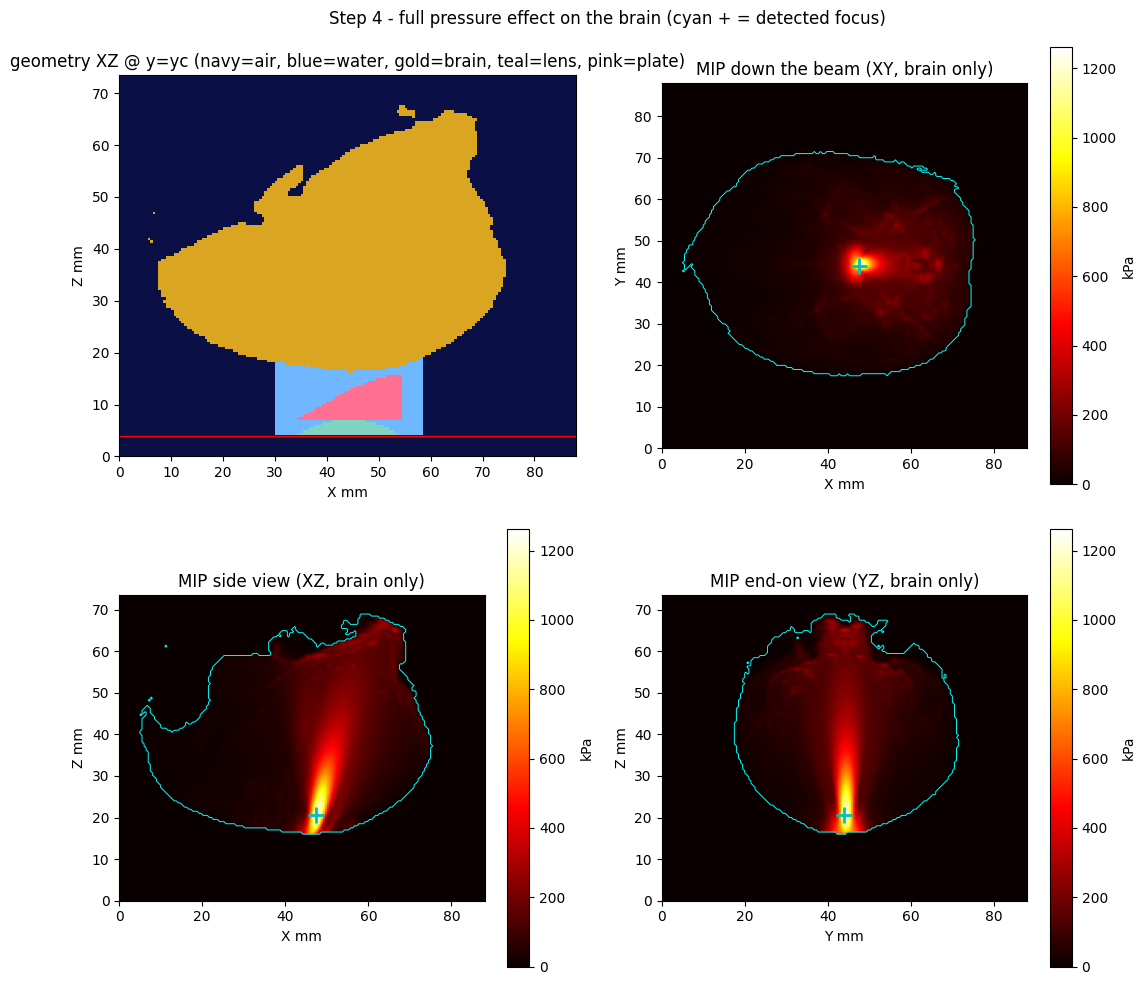

In [30]:
ex=[0,Nx*dx*1e3]; ez=[0,Nz*dx*1e3]; ey=[0,Ny*dx*1e3]
cmap4=plt.matplotlib.colors.ListedColormap(["#0a1045","#6fb8ff","#daa520","#7fd4c1","#ff6f91"])  # air,water,brain,lens,plate

# full effect on the brain: max-intensity projections (brain tissue only), not just one slice,
# so an off-axis or steered focus can't hide outside a single chosen plane
pB = np.where(brain_W, p4, 0.0)
mip_xy = pB.max(2); mip_xz = pB.max(1); mip_yz = pB.max(0)   # down-the-beam / side / end-on
vmax = pB.max()/1e3

fig,ax=plt.subplots(2,2,figsize=(11,10))
ax[0,0].imshow(tissue[:,yc,:].T,origin="lower",extent=ex+ez,cmap=cmap4,vmin=0,vmax=4,aspect="equal",interpolation="nearest")
ax[0,0].axhline(z_face*dx*1e3,c="r",lw=1)
ax[0,0].set(title="geometry XZ @ y=yc (navy=air, blue=water, gold=brain, teal=lens, pink=plate)",xlabel="X mm",ylabel="Z mm")

im=ax[0,1].imshow(mip_xy.T/1e3,origin="lower",extent=ex+ey,cmap="hot",vmin=0,vmax=vmax,aspect="equal")
ax[0,1].contour(brain_W.any(2).T,levels=[0.5],colors="cyan",linewidths=0.7,extent=ex+ey,origin="lower")
ax[0,1].plot(fi4[0]*dx*1e3, fi4[1]*dx*1e3,"c+",ms=12,mew=2)
ax[0,1].set(title="MIP down the beam (XY, brain only)",xlabel="X mm",ylabel="Y mm"); plt.colorbar(im,ax=ax[0,1],label="kPa")

im=ax[1,0].imshow(mip_xz.T/1e3,origin="lower",extent=ex+ez,cmap="hot",vmin=0,vmax=vmax,aspect="equal")
ax[1,0].contour(brain_W.any(1).T,levels=[0.5],colors="cyan",linewidths=0.7,extent=ex+ez,origin="lower")
ax[1,0].plot(fi4[0]*dx*1e3, fi4[2]*dx*1e3,"c+",ms=12,mew=2)
ax[1,0].set(title="MIP side view (XZ, brain only)",xlabel="X mm",ylabel="Z mm"); plt.colorbar(im,ax=ax[1,0],label="kPa")

im=ax[1,1].imshow(mip_yz.T/1e3,origin="lower",extent=ey+ez,cmap="hot",vmin=0,vmax=vmax,aspect="equal")
ax[1,1].contour(brain_W.any(0).T,levels=[0.5],colors="cyan",linewidths=0.7,extent=ey+ez,origin="lower")
ax[1,1].plot(fi4[1]*dx*1e3, fi4[2]*dx*1e3,"c+",ms=12,mew=2)
ax[1,1].set(title="MIP end-on view (YZ, brain only)",xlabel="Y mm",ylabel="Z mm"); plt.colorbar(im,ax=ax[1,1],label="kPa")

plt.suptitle("Step 4 - full pressure effect on the brain (cyan + = detected focus)")
plt.tight_layout(); plt.show()

## 5. Simulate the reachable-volume extremes on the brain

Pick a handful of boundary points from the reachable-volume sweep (a few lateral offsets, each at its shallowest
and deepest still-feasible depth), aim a *targeted* phase plate at each (reusing the Step 4 pose), and actually
simulate them. Each point gets its own small LOCAL crop sized just for that target -- not the whole brain -- since
we already know roughly where to look from the math above, so this is much cheaper than Step 4's whole-brain run
per point. Expect this to take a while regardless: it's N simulations back to back, just smaller ones.

In [31]:
# a few lateral offsets (as fractions of the max feasible lateral), each at its shallowest/deepest
# still-feasible depth -- trim the fractions list to run fewer/cheaper points
lat_feasible = feasible.any(0)
li_max = np.where(lat_feasible)[0].max()
test_li = sorted(set(int(f*li_max) for f in [0.0, 0.5, 0.85, 1.0]))
targets = []                                              # (lat_m, z_m, label)
for li in test_li:
    col = feasible[:, li]
    if not col.any(): continue
    zs = z_grid[col]; lat_m = lat_grid[li]
    targets.append((lat_m, zs.min(), f"lat{lat_m*1e3:.0f}_shallow"))
    if zs.max() > zs.min():
        targets.append((lat_m, zs.max(), f"lat{lat_m*1e3:.0f}_deep"))
print(f"{len(targets)} extreme points to simulate:")
for lat_m, z_m, lbl in targets: print(f"  {lbl}: lateral {lat_m*1e3:.0f}mm, depth {z_m*1e3:.0f}mm")

8 extreme points to simulate:
  lat0_shallow: lateral 0mm, depth 6mm
  lat0_deep: lateral 0mm, depth 60mm
  lat7_shallow: lateral 7mm, depth 28mm
  lat7_deep: lateral 7mm, depth 60mm
  lat11_shallow: lateral 11mm, depth 49mm
  lat11_deep: lateral 11mm, depth 60mm
  lat14_shallow: lateral 14mm, depth 59mm
  lat14_deep: lateral 14mm, depth 60mm


In [33]:
PML_SIZE = 20   # k-Wave's default pml_size (grid points); validate_pml requires 2*PML_SIZE < N on every axis

def run_target_sim(lat_t, z_t):
    # small LOCAL crop sized just for this one target (not the whole brain), reusing the Step 4 pose
    # (face_vox, e1, e2, e3, Mrot) -- target sits at lateral offset lat_t along e1, depth z_t along e3
    margin = 8e-3
    LATc = max(int(np.ceil(m2v(abs(lat_t) + r_tx + margin))), PML_SIZE + 1)
    Zc   = max(Z_MARGIN + int(np.ceil(m2v(z_t + margin))), 2*PML_SIZE + 1)
    Nxc = Nyc = 2*LATc; xcc = ycc = LATc; zfc = Z_MARGIN
    origin_c = face_vox - e3*zfc
    offset_c = origin_c - Mrot.T @ np.array([xcc, ycc, 0.])
    brain_c = ndimage.affine_transform(brain.astype(np.float32), matrix=Mrot.T, offset=offset_c,
                                        output_shape=(Nxc,Nyc,Zc), order=1) > 0.5

    surfz_c = np.full((Nxc,Nyc), Zc, int); anyb_c = brain_c.any(2); surfz_c[anyb_c] = brain_c.argmax(2)[anyb_c]
    xxc,yyc = np.meshgrid(np.arange(Nxc),np.arange(Nyc),indexing="ij")
    r2d_c = np.sqrt(((xxc-xcc)*dx)**2+((yyc-ycc)*dx)**2); zzc = np.arange(Zc)[None,None,:]
    couple_c = (r2d_c<=R_COUPLE)[:,:,None] & (zzc>=zfc) & (zzc<surfz_c[:,:,None]) & ~brain_c

    c_map_c   = np.full((Nxc,Nyc,Zc), c_air,   np.float32)
    rho_map_c = np.full((Nxc,Nyc,Zc), rho_air, np.float32)
    c_map_c[couple_c]=c_med;  rho_map_c[couple_c]=rho_med
    c_map_c[brain_c]=c_med;   rho_map_c[brain_c]=rho_med
    lens_c = stamp_lens(c_map_c, rho_map_c, zfc, xcc, ycc)

    target_vox = (xcc + m2v(lat_t), ycc, zfc + m2v(z_t))
    plate_t = targeted_plate_thickness(Nxc, Nyc, xcc, ycc, zfc, target_vox)
    z_plate_c = zfc + int(lens_c.sum(2).max())
    stamp_plate(c_map_c, rho_map_c, z_plate_c, plate_t)

    t_end_c = 1.2*(Zc*dx)/c_med
    p_c = run_sim(c_map_c.copy(), rho_map_c.copy(), zfc, xcc, ycc, t_end_c)
    fi_c, pk_c = focus_of(p_c, mask=brain_c)

    return dict(
        lat_mm=lat_t*1e3, z_mm=z_t*1e3, plate_max_mm=plate_t.max()*1e3, peak_kPa=pk_c/1e3,
        global_target=face_vox + (lat_t/dx)*e1 + (z_t/dx)*e3,
        global_focus=face_vox + (fi_c[0]-xcc)*e1 + (fi_c[1]-ycc)*e2 + (fi_c[2]-zfc)*e3,
        achieved_lat_mm=np.hypot(fi_c[0]-xcc, fi_c[1]-ycc)*dx*1e3,
        achieved_z_mm=(fi_c[2]-zfc)*dx*1e3)

results = []
for i, (lat_t, z_t, lbl) in enumerate(targets):
    print(f"[{i+1}/{len(targets)}] {lbl}: target lateral {lat_t*1e3:.0f}mm depth {z_t*1e3:.0f}mm")
    results.append(run_target_sim(lat_t, z_t))
    r = results[-1]
    print(f"  -> achieved lateral {r['achieved_lat_mm']:.1f}mm depth {r['achieved_z_mm']:.1f}mm, "
          f"plate max {r['plate_max_mm']:.2f}mm, peak {r['peak_kPa']:.0f} kPa")

[1/8] lat0_shallow: target lateral 0mm depth 6mm
  grid 72x72x41  Nt 166  ... running (GPU)


k-Wave: 100%|██████████| 166/166 [00:00<00:00, 298.98step/s]


  -> achieved lateral 0.0mm depth 12.0mm, plate max 7.29mm, peak 827 kPa
[2/8] lat0_deep: target lateral 0mm depth 60mm
  grid 72x72x144  Nt 578  ... running (GPU)


k-Wave: 100%|██████████| 578/578 [00:42<00:00, 13.55step/s]


  -> achieved lateral 0.0mm depth 22.0mm, plate max 1.62mm, peak 793 kPa
[3/8] lat7_shallow: target lateral 7mm depth 28mm
  grid 100x100x80  Nt 321  ... running (GPU)


...

  -> achieved lateral 3.5mm depth 21.5mm, plate max 6.60mm, peak 846 kPa
[7/8] lat14_shallow: target lateral 14mm depth 59mm
  grid 128x128x142  Nt 570  ... running (GPU)


k-Wave: 100%|██████████| 570/570 [00:28<00:00, 19.83step/s]


  -> achieved lateral 4.0mm depth 20.5mm, plate max 7.95mm, peak 838 kPa
[8/8] lat14_deep: target lateral 14mm depth 60mm
  grid 128x128x144  Nt 578  ... running (GPU)


k-Wave: 100%|██████████| 578/578 [00:28<00:00, 20.29step/s]


  -> achieved lateral 4.0mm depth 21.0mm, plate max 7.78mm, peak 838 kPa


### Show the extremes on the brain

C:\Users\bengi\AppData\Local\Temp\ipykernel_64240\1999674927.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


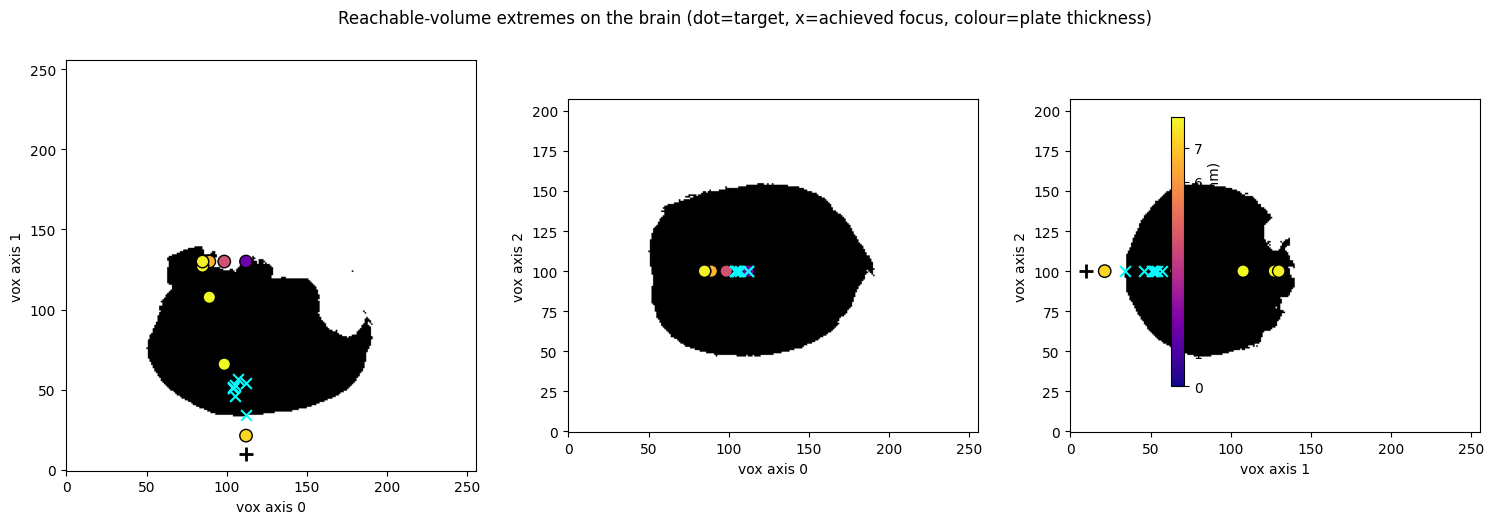


label           lat_mm   z_mm  plate_mm  peak_kPa  achiev_lat  achiev_z
lat0_shallow       0.0    5.7      7.29       827         0.0      12.0
lat0_deep          0.0   60.0      1.62       793         0.0      22.0
lat7_shallow       6.8   28.0      7.97      1102         3.5      18.0
lat7_deep          6.8   60.0      4.21       801         2.5      23.5
lat11_shallow     11.4   48.9      7.99       881         4.0      20.5
lat11_deep        11.4   60.0      6.60       846         3.5      21.5
lat14_shallow     13.6   58.6      7.95       838         4.0      20.5
lat14_deep        13.6   60.0      7.78       838         4.0      21.0


In [34]:
bij = brain.any(2); bik = brain.any(1); bjk = brain.any(0)
thicknesses = [r['plate_max_mm'] for r in results]
fig, ax = plt.subplots(1, 3, figsize=(15,5))
for a, foot, (h,v) in zip(ax, [bij,bik,bjk], [(0,1),(0,2),(1,2)]):
    a.imshow(foot.T, origin="lower", cmap="gray_r", aspect="equal")
    a.plot(face_vox[h], face_vox[v], "k+", ms=10, mew=2)
    sca = a.scatter([r['global_target'][h] for r in results], [r['global_target'][v] for r in results],
                     c=thicknesses, cmap="plasma", s=80, edgecolor="k", zorder=5, vmin=0, vmax=T_BUDGET*1e3)
    a.scatter([r['global_focus'][h] for r in results], [r['global_focus'][v] for r in results],
              marker="x", c="cyan", s=60, zorder=6)
    a.set(xlabel=f"vox axis {h}", ylabel=f"vox axis {v}")
plt.colorbar(sca, ax=ax, label="plate max thickness (mm)", shrink=0.7)
fig.suptitle("Reachable-volume extremes on the brain (dot=target, x=achieved focus, colour=plate thickness)")
plt.tight_layout(); plt.show()

print(f"\n{'label':14s} {'lat_mm':>7s} {'z_mm':>6s} {'plate_mm':>9s} {'peak_kPa':>9s} {'achiev_lat':>11s} {'achiev_z':>9s}")
for (lat_t,z_t,lbl), r in zip(targets, results):
    print(f"{lbl:14s} {r['lat_mm']:7.1f} {r['z_mm']:6.1f} {r['plate_max_mm']:9.2f} {r['peak_kPa']:9.0f} "
          f"{r['achieved_lat_mm']:11.1f} {r['achieved_z_mm']:9.1f}")

## 6. Sanity check: thickness budget, or reflection/resonance?

`lat0_deep` (on-axis, target 60mm) only needed ~1.6mm of plate -- well under the ~8mm budget -- yet the achieved
focus landed at ~22mm regardless. That rules out the thickness budget as the limiting factor for this case, so
simply freeing up more budget (e.g. by not anchoring to a fixed lens) shouldn't move it much. Re-running it with
the lens/plate's acoustic impedance pulled much closer to brain (weaker reflection at the silicone/brain
interface) tests whether reflection/resonance inside the thin slow-silicone stack -- not the phase design
itself -- is what's actually capping depth.

In [35]:
# TEMP material override -- re-run the Parameters cell afterward to restore the real silicone values
c_lens_real, rho_lens_real = c_lens, rho_lens
c_lens, rho_lens = 1300.0, 1035.0                 # much closer to brain (1560/1040) -> weaker reflection
Z_real, Z_test, Z_brain = c_lens_real*rho_lens_real, c_lens*rho_lens, c_med*rho_med
print(f"pressure reflection coeff at silicone/brain: real {(Z_brain-Z_real)/(Z_brain+Z_real):.3f}  "
      f"test {(Z_brain-Z_test)/(Z_brain+Z_test):.3f}")

r = run_target_sim(0.0, 60e-3)
print(f"lat0_deep with reduced mismatch: target depth 60mm -> achieved {r['achieved_z_mm']:.1f}mm "
      f"(was 22.0mm with real silicone), plate {r['plate_max_mm']:.2f}mm, peak {r['peak_kPa']:.0f}kPa")

c_lens, rho_lens = c_lens_real, rho_lens_real     # restore real values

pressure reflection coeff at silicone/brain: real 0.223  test 0.093
  grid 72x72x144  Nt 578  ... running (GPU)


k-Wave: 100%|██████████| 578/578 [00:30<00:00, 19.03step/s]


lat0_deep with reduced mismatch: target depth 60mm -> achieved 20.0mm (was 22.0mm with real silicone), plate 4.52mm, peak 617kPa
